In [1]:

[
# Run this cell once to ensure all required libraries are installed.
# Core Data Science & Math Libraries
#%pip install numpy pandas scipy scikit-learn

# Data Visualization & Presentation
# %pip install matplotlib seaborn

# Deep Learning Framework
# %pip install tensorflow

# Interactive Jupyter Widgets (For the Scouting & Simulator tools)
# %pip install ipywidgets

# 3D Neural Network Architecture Visualizer (Optional but recommended)
# %pip install visualkeras pillow

# Note: If widgets do not display correctly in JupyterLab, you may also need:
# %pip install jupyterlab_widgets
]

[]

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from scipy.signal import butter, filtfilt
from math import pi
import ipywidgets as widgets
from IPython.display import display, clear_output

sns.set_theme(style="whitegrid")


In [ ]:
#run Tennis_MLP_CSV_Sorter_v1 to adjust data set if any faulty labeling happens

In [3]:
# 1. CONFIGURATION & 10-CLASS DICTIONARY

DATA_DIR = r"C:\Users\sheri\OneDrive\Desktop\tennisDS1" #file directory
RADIUS = 40  
TARGET_COLUMNS = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'accel_mag', 'gyro_mag']
ROWS_TO_DROP = 500

# 10 Distinct Classes for Left, Right Detection
LABEL_MAP = {
    'a01': 'serve_right',           'a02': 'serve_left',
    'a03': 'forehand_right',        'a04': 'forehand_left',
    'a05': 'backhand_right_1_arm',  'a06': 'backhand_left_1_arm',
    'a07': 'backhand_right_2_arms', 'a08': 'backhand_left_2_arms',
    'a09': 'overhead_right',        'a10': 'overhead_left',
}


In [4]:
# 2.HUMAN TENSOR EXTRACTION 

print("Initiating Peak-Aligned Pure Human Tensor Extraction (10-Class)...")
search_pattern = os.path.join(DATA_DIR, "**", "*_Accelerometer.csv")
accel_files = glob.glob(search_pattern, recursive=True)

X_blocks, y_labels, person_ids, master_df_data = [], [], [], []

for accel_path in accel_files:
    gyro_path = accel_path.replace("Accelerometer", "Gyroscope")
    if not os.path.exists(gyro_path): continue
    
    filename = os.path.basename(accel_path)
    parts = filename.split('_')
    if len(parts) < 2: continue
    
    action_code, person_id = parts[0].lower(), parts[1].upper()
    if action_code not in LABEL_MAP: continue
    action_label = LABEL_MAP[action_code]
    
    try:
        accel_df = pd.read_csv(accel_path).rename(columns={'x': 'accel_x', 'y': 'accel_y', 'z': 'accel_z'})
        gyro_df = pd.read_csv(gyro_path).rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})
        merged = accel_df[['time', 'accel_x', 'accel_y', 'accel_z']].merge(
            gyro_df[['time', 'gyro_x', 'gyro_y', 'gyro_z']], on='time'
        )
        
        if len(merged) > ROWS_TO_DROP: merged = merged.iloc[ROWS_TO_DROP:].reset_index(drop=True)
        else: continue
        
        merged['accel_mag'] = np.sqrt(merged['accel_x']**2 + merged['accel_y']**2 + merged['accel_z']**2)
        merged['gyro_mag'] = np.sqrt(merged['gyro_x']**2 + merged['gyro_y']**2 + merged['gyro_z']**2)
        
        # Keep a raw copy for the Radar Charts
        raw_mag_max = merged['accel_mag'].max()
        
        scaler = StandardScaler()
        merged[TARGET_COLUMNS] = scaler.fit_transform(merged[TARGET_COLUMNS])
        
        peaks, _ = scipy.signal.find_peaks(merged['accel_mag'], distance=80, prominence=1.5)
        
        for peak in peaks:
            start_idx, end_idx = peak - RADIUS, peak + RADIUS
            if start_idx >= 0 and end_idx < len(merged):
                window = merged.iloc[start_idx:end_idx].copy()
                
                # Zero-Center Directional Axes
                directional_cols = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
                for col in directional_cols:
                    window[col] = window[col] - window[col].iloc[0]
                
                base_tensor = window[TARGET_COLUMNS].values
                
                X_blocks.append(base_tensor)
                y_labels.append(action_label)
                person_ids.append(person_id)
                
                master_df_data.append({
                    'person_id': person_id,
                    'action_label': action_label,
                    'accel_mag_max': raw_mag_max
                })
                    
    except Exception as e:
        continue

X_all = np.array(X_blocks)
person_array = np.array(person_ids)
master_df = pd.DataFrame(master_df_data)

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(y_labels)
num_classes = len(np.unique(y_all))

print(f"Extraction complete: Generated {X_all.shape[0]} Clean Human Tensors.")


Initiating Peak-Aligned Pure Human Tensor Extraction (10-Class)...
Extraction complete: Generated 1061 Clean Human Tensors.


In [5]:
# 3. FEW-SHOT CALIBRATION DATA SPLIT 
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
stratify_labels = [f"{p}_{l}" for p, l in zip(person_array, y_all)]

train_idx, test_idx = next(sss.split(X_all, stratify_labels))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"Calibration Complete -> Train: {len(X_train)} | Test: {len(X_test)}")


Calibration Complete -> Train: 848 | Test: 213


In [6]:
# 4. 10-CLASS MLP ARCHITECTURE
inputs = Input(shape=(RADIUS * 2, len(TARGET_COLUMNS)))
x = Flatten()(inputs)

x = Dense(256)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.4)(x)  

x = Dense(128)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)

x = Dense(64)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.2)(x)

outputs = Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)


In [7]:
# 5. TRAINING (ADAMW + COSINE ANNEALING)
batch_size = 32 
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))

lr_schedule = CosineDecayRestarts(
    initial_learning_rate=1e-3, first_decay_steps=steps_per_epoch * 10, t_mul=2.0, m_mul=0.8, alpha=1e-5  
)
optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nTraining 10-Class MLP Engine...")
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history = model.fit(
    X_train, y_train, 
    epochs=70, 
    batch_size=batch_size, 
    validation_data=(X_test, y_test), 
    callbacks=[early_stop], 
    verbose=1
)



Training 10-Class MLP Engine...
Epoch 1/70
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2795 - loss: 2.0734 - val_accuracy: 0.5352 - val_loss: 1.3532
Epoch 2/70
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5106 - loss: 1.5144 - val_accuracy: 0.6854 - val_loss: 0.9513
Epoch 3/70
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6368 - loss: 1.2018 - val_accuracy: 0.7559 - val_loss: 0.7531
Epoch 4/70
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7005 - loss: 1.0239 - val_accuracy: 0.8310 - val_loss: 0.6168
Epoch 5/70
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7288 - loss: 0.9335 - val_accuracy: 0.8545 - val_loss: 0.5594
Epoch 6/70
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7677 - loss: 0.8855 - val_accuracy: 0.8826 - val_loss: 0.5162
Epoch 7/70
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8078 - loss: 0.7590 - val_accuracy: 0.8920 - val_loss: 0.4930
Epoch 8/70
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8066 - loss: 0.7394 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10-CLASS MLP DIAGNOSTICS
GLOBAL ACCURACY : 93.9%


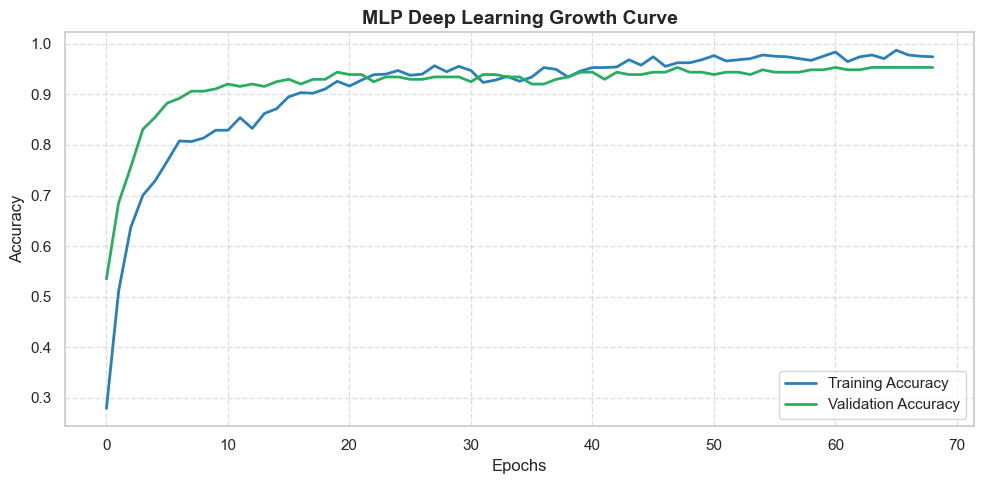

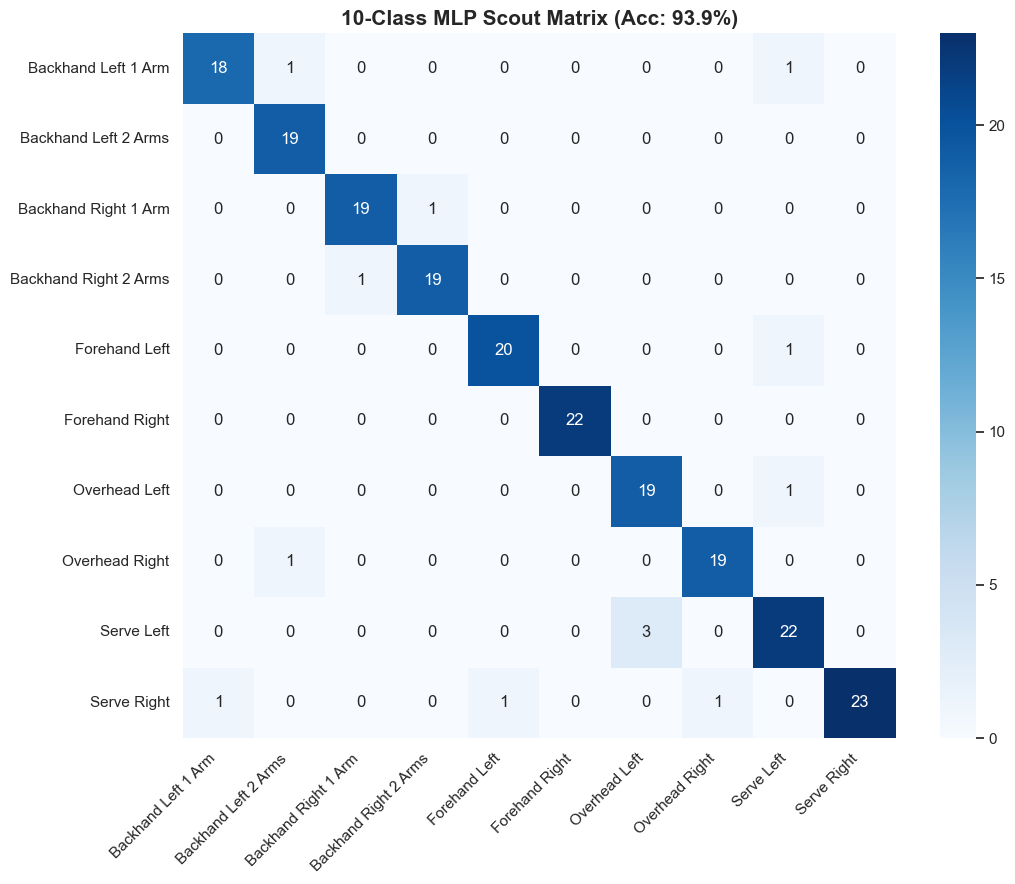

In [8]:
# 6. EVALUATION, SCOUT MATRIX & LEARNING CURVE
predictions = model.predict(X_test)
pred_classes = np.argmax(predictions, axis=1)

global_acc = np.mean(pred_classes == y_test) * 100

print(f"10-CLASS MLP DIAGNOSTICS")
print(f"GLOBAL ACCURACY : {global_acc:.1f}%")


# --- Deep Learning Growth Curve ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], color='#2980b9', linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='#27ae60', linewidth=2, label='Validation Accuracy')
plt.title('MLP Deep Learning Growth Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 10-Class Scout Matrix ---
decoded_y_true = label_encoder.inverse_transform(y_test)
decoded_y_pred = label_encoder.inverse_transform(pred_classes)

plt.figure(figsize=(11, 9))
labels = sorted(list(set(decoded_y_true)))
pretty_labels = [str(label).replace('_', ' ').title() for label in labels]

cm = confusion_matrix(decoded_y_true, decoded_y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pretty_labels, yticklabels=pretty_labels)
plt.title(f'10-Class MLP Scout Matrix (Acc: {global_acc:.1f}%)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [9]:

# 7. INTERACTIVE SCOUTING DASHBOARD & BIOMECHANICS PLOT
def butter_lowpass_filter(data, cutoff=20.0, fs=100.0, order=4):
    if len(data) <= order * 3: return data
    nyq  = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='low', analog=False)
    return filtfilt(b, a, data)

if len(master_df) > 0:
    
    unique_players = sorted(master_df['person_id'].unique())

    def plot_player_profile(player):
        player_data = master_df[master_df['person_id'] == player]
        
        right_data = player_data[player_data['action_label'].str.contains('right')]
        left_data  = player_data[player_data['action_label'].str.contains('left')]
        
        right_swings, left_swings = len(right_data), len(left_data)
        total_swings = right_swings + left_swings
        
        if total_swings > 0:
            right_pct = (right_swings / total_swings) * 100
            left_pct  = (left_swings / total_swings) * 100
            
            right_power = right_data['accel_mag_max'].mean() if right_swings > 0 else 0
            left_power  = left_data['accel_mag_max'].mean() if left_swings > 0 else 0
            
            action_power = player_data.groupby('action_label')['accel_mag_max'].mean()
            strongest_stroke = action_power.idxmax()
            strongest_gforce = action_power.max()
            
            if right_pct >= 65: 
                handedness = f"Dominant Right (Vol: {right_pct:.0f}% | Avg Power: {right_power:.1f}G)"
            elif left_pct >= 65: 
                handedness = f"Dominant Left (Vol: {left_pct:.0f}% | Avg Power: {left_power:.1f}G)"
            else:
                if 'right' in strongest_stroke and right_power > left_power:
                    handedness = f"Ambidextrous (Right Power Dominant | Max: {strongest_gforce:.1f}G)"
                elif 'left' in strongest_stroke and left_power > right_power:
                    handedness = f"Ambidextrous (Left Power Dominant | Max: {strongest_gforce:.1f}G)"
                else:
                    handedness = f"True Ambidextrous (Balanced Volume & Physics)"
        else:
            handedness, action_power, strongest_stroke = "Unknown Data", pd.Series(dtype=float), "None"

        if not action_power.empty:
            radar_labels = [lbl.replace('_', ' ').title() for lbl in action_power.index]
            radar_values = action_power.values.tolist()
            radar_values += radar_values[:1]
            angles  = np.linspace(0, 2 * pi, len(radar_labels), endpoint=False).tolist()
            angles += angles[:1]

            # FIX: Create a taller canvas
            fig = plt.figure(figsize=(8, 9))
            
            # FIX: Hardcode the axes. [left, bottom, width, height].
            # A height of 0.65 forces the chart to stay low, leaving the top wide open.
            ax = fig.add_axes([0.1, 0.05, 0.8, 0.65], polar=True)
            
            ax.plot(angles, radar_values, color='#8e44ad', linewidth=2.5, marker='o')
            ax.fill(angles, radar_values, color='#8e44ad', alpha=0.25)
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels([])

            for angle, label in zip(angles[:-1], radar_labels):
                deg = np.degrees(angle)
                rotation  = (deg + 180) if 90 <= deg <= 270 else deg
                alignment = 'right' if 90 <= deg <= 270 else 'left'
                
                ax.text(angle, max(radar_values) * 1.3, label,
                        rotation=rotation, rotation_mode='anchor',
                        ha=alignment, va='center', fontsize=10, fontweight='bold')

            ax.set_yticks(np.linspace(0, max(radar_values), 5))
            ax.set_yticklabels([])
            
            # FIX: Use suptitle anchored to the very top (y=0.92) so it hovers far above the radar axes
            fig.suptitle(f"Profile: {player}\n{handedness}\nStrongest Move: {strongest_stroke.replace('_', ' ').title()}", 
                         size=15, fontweight='bold', y=0.92)
            
            plt.show()

    player_dropdown = widgets.Dropdown(options=unique_players, description='Select Player:')
    display(widgets.interactive(plot_player_profile, player=player_dropdown))

    all_moves = sorted(set(LABEL_MAP.values()))
    pretty_moves = [m.replace('_', ' ').title() for m in all_moves]
    move_dict = dict(zip(pretty_moves, all_moves))

    def plot_biomechanics(selected_pretty_move):
        target_move = move_dict[selected_pretty_move]
        target_code = [k for k, v in LABEL_MAP.items() if v == target_move][0]

        athlete_files = {}
        for filepath in accel_files:
            parts = os.path.basename(filepath).split('_')
            if (len(parts) >= 2 and parts[0].lower() == target_code and parts[1].upper() not in athlete_files):
                gyro_path = filepath.replace("Accelerometer", "Gyroscope")
                if os.path.exists(gyro_path):
                    athlete_files[parts[1].upper()] = (filepath, gyro_path)

        if not athlete_files:
            print(f"Not enough data to compare: {selected_pretty_move}.")
            return

        n_ath = len(athlete_files)
        fig, axes = plt.subplots(2, n_ath, figsize=(5 * n_ath, 6), sharex=False)
        fig.suptitle(f"Raw Physics: {selected_pretty_move}", fontsize=16, fontweight='bold', y=1.05)

        for i, (person, paths) in enumerate(sorted(athlete_files.items())):
            raw_accel = pd.read_csv(paths[0]).rename(columns={'x': 'ax', 'y': 'ay', 'z': 'az'})
            raw_gyro  = pd.read_csv(paths[1]).rename(columns={'x': 'gx', 'y': 'gy', 'z': 'gz'})
            merged = raw_accel[['time', 'ax', 'ay', 'az']].merge(raw_gyro[['time', 'gx', 'gy', 'gz']], on='time')

            if len(merged) > ROWS_TO_DROP: merged = merged.iloc[ROWS_TO_DROP:].reset_index(drop=True)
            for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
                merged[col] = butter_lowpass_filter(merged[col].dropna())

            merged['mag'] = np.sqrt(merged['ax']**2 + merged['ay']**2 + merged['az']**2)
            peak_idx = merged['mag'].idxmax()
            zoom_df  = merged.iloc[max(0, peak_idx - 60): min(len(merged), peak_idx + 60)].copy()
            zoom_df['time'] = zoom_df['time'] - zoom_df['time'].iloc[0]

            ax_accel = axes[0, i] if n_ath > 1 else axes[0]
            ax_accel.plot(zoom_df['time'], zoom_df['ax'], color='#e74c3c', linewidth=2)
            ax_accel.plot(zoom_df['time'], zoom_df['ay'], color='#2ecc71', linewidth=2)
            ax_accel.plot(zoom_df['time'], zoom_df['az'], color='#3498db', linewidth=2)
            ax_accel.set_title(f"{person} — Acceleration", fontweight='bold')

            ax_gyro = axes[1, i] if n_ath > 1 else axes[1]
            ax_gyro.plot(zoom_df['time'], zoom_df['gx'], color='#e74c3c', linewidth=2)
            ax_gyro.plot(zoom_df['time'], zoom_df['gy'], color='#2ecc71', linewidth=2)
            ax_gyro.plot(zoom_df['time'], zoom_df['gz'], color='#3498db', linewidth=2)
            ax_gyro.set_title(f"{person} — Rotation", fontweight='bold')

        plt.tight_layout()
        plt.show()

    move_dropdown = widgets.Dropdown(options=pretty_moves, value=pretty_moves[0], description='Select Move:')
    display(widgets.interactive(plot_biomechanics, selected_pretty_move=move_dropdown))

interactive(children=(Dropdown(description='Select Player:', options=('AA000000', 'OH000000', 'SH000000', 'SH0…

interactive(children=(Dropdown(description='Select Move:', options=('Backhand Left 1 Arm', 'Backhand Left 2 Ar…

In [10]:

# 8.MLP FORWARD PASS SIMULATOR

import matplotlib.patches as patches

# Network Blueprint: (Visual Nodes, True Nodes, Dropout Rate, Layer Name)
layer_configs = [
    (20, 640, 0.0, "Input\n(Flattened Tensor)"),
    (16, 256, 0.4, "Dense 1\n(ReLU)"),
    (12, 128, 0.3, "Dense 2\n(ReLU)"),
    (8,  64,  0.2, "Dense 3\n(ReLU)"),
    (6,  10,  0.0, "Output\n(Softmax)")
]

def simulate_forward_pass(step):
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.axis('off')
    
    # FIX: Lock the Y-axis explicitly so the text has plenty of empty space
    ax.set_ylim(-14, 14)
    
    x_spacing = 2
    x_positions = [i * x_spacing for i in range(len(layer_configs))]
    y_positions = []
    
    # Calculate positions for nodes in each layer to keep them vertically centered
    for num_nodes, _, _, _ in layer_configs:
        y_start = (num_nodes - 1) / 2.0
        y_positions.append([y_start - i for i in range(num_nodes)])
        
    for i in range(len(layer_configs) - 1):
        for y1 in y_positions[i]:
            for y2 in y_positions[i+1]:
                ax.plot([x_positions[i], x_positions[i+1]], [y1, y2], color='gray', alpha=0.1, zorder=1)

    for i, (num_nodes, true_nodes, dropout_rate, name) in enumerate(layer_configs):
        x = x_positions[i]
        
        for j, y in enumerate(y_positions[i]):
            color = '#bdc3c7'
            
            if step > i:
                color = '#3498db'  
                if dropout_rate > 0:
                    np.random.seed(j * (i+1)) 
                    if np.random.rand() < dropout_rate:
                        color = '#e74c3c'  
                        
                if i == len(layer_configs) - 1:
                    color = '#2ecc71'
                    
            ax.scatter(x, y, s=250, color=color, edgecolor='white', linewidth=1.5, zorder=2)
            
        status = "Inactive"
        if step > i:
            status = "Processing..." if dropout_rate == 0 else f"Dropout: {int(dropout_rate*100)}%"
            if i == len(layer_configs) - 1: status = "Classified!"
            
        # FIX: Anchored the text securely to +/- 11.5 to completely avoid node overlapping
        ax.text(x, 11.5, f"{name}", ha='center', fontweight='bold', fontsize=11)
        ax.text(x, -11.5, f"Nodes: {true_nodes}\n[{status}]", ha='center', fontsize=9, 
                color='#2c3e50' if step > i else 'gray')

    titles = [
        "Awaiting Data...",
        "Step 1: Raw 640-Feature Tensor Fed into Input Layer",
        "Step 2: Dense 1 extracts patterns (40% Nodes Randomly Dropped)",
        "Step 3: Dense 2 compresses physics (30% Nodes Randomly Dropped)",
        "Step 4: Dense 3 isolates handedness/stroke (20% Nodes Randomly Dropped)",
        "Step 5: Softmax Output generates final probability (10 Classes)"
    ]
    plt.title(titles[step], fontsize=15, fontweight='bold', pad=15, color='#2c3e50')
    plt.tight_layout()
    plt.show()

step_slider = widgets.IntSlider(min=0, max=5, step=1, value=0, description='Data Step:')
display(widgets.interactive(simulate_forward_pass, step=step_slider))

interactive(children=(IntSlider(value=0, description='Data Step:', max=5), Output()), _dom_classes=('widget-in…

In [11]:
# 9.GAUSSIAN NOISE STRESS TEST (OVERFITTING DIAGNOSTIC)
import numpy as np

print(" GAUSSIAN NOISE STRESS TEST INITIATED")

# Store the baseline accuracy of the clean test set
clean_predictions = model.predict(X_test, verbose=0)
clean_acc = np.mean(np.argmax(clean_predictions, axis=1) == y_test) * 100
print(f"Baseline (Clean) Accuracy : {clean_acc:.1f}%")

# Define escalating levels of sensor noise
noise_levels = [0.05, 0.10, 0.20, 0.50]
noise_results = []

for noise_multiplier in noise_levels:
    # Generate random mathematical static
    # multiply by the standard deviation of the test set to scale the noise appropriately
    std_dev = np.std(X_test)
    static_noise = np.random.normal(loc=0.0, scale=std_dev * noise_multiplier, size=X_test.shape)
    
    # Corrupt the test data
    X_test_corrupted = X_test + static_noise
    
    # Force the model to predict on the corrupted data
    corrupted_predictions = model.predict(X_test_corrupted, verbose=0)
    corrupted_acc = np.mean(np.argmax(corrupted_predictions, axis=1) == y_test) * 100
    
    noise_results.append((noise_multiplier * 100, corrupted_acc))
    print(f"Accuracy w/ {noise_multiplier*100:.0f}% Noise : {corrupted_acc:.1f}%")

print("\n--- DIAGNOSTIC CONCLUSION ---")
# If the model survives 10% noise with only a minor drop, it is structurally robust.
if noise_results[1][1] >= (clean_acc - 15.0):
    print("SUCCESS: Your model is HIGHLY ROBUST. It learned the true shape of the swings and easily ignores sensor interference. It is NOT overfitted.")
else:
    print("WARNING: Your model suffered a catastrophic collapse from minor noise. It may be overfitted to exact numeric values.")

 GAUSSIAN NOISE STRESS TEST INITIATED
Baseline (Clean) Accuracy : 93.9%
Accuracy w/ 5% Noise : 93.9%
Accuracy w/ 10% Noise : 93.9%
Accuracy w/ 20% Noise : 93.9%
Accuracy w/ 50% Noise : 92.0%

--- DIAGNOSTIC CONCLUSION ---
SUCCESS: Your model is HIGHLY ROBUST. It learned the true shape of the swings and easily ignores sensor interference. It is NOT overfitted.


In [12]:

# 10.AUTOMATED ROBUSTNESS EVALUATION (MONTE CARLO CROSS-VALIDATION)
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
import numpy as np

NUM_RUNS = 5  # variable depending on no. of tests
run_accuracies = []

print(f"Initiating {NUM_RUNS}-Run Monte Carlo Cross-Validation...\n")

for run in range(NUM_RUNS):
    print(f"--- STARTING RUN {run + 1} OF {NUM_RUNS} ---")
    
    # FIX: Wipe TensorFlow's memory before building the new model to prevent retracing warnings
    tf.keras.backend.clear_session()
    
    # 1. NEW RANDOM SPLIT: We add 'run' to the random_state so every loop tests a DIFFERENT split
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42 + run)
    stratify_labels = [f"{p}_{l}" for p, l in zip(person_array, y_all)]
    
    train_idx, test_idx = next(sss.split(X_all, stratify_labels))
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    
    # 2. BUILD A FRESH MLP
    inputs = Input(shape=(RADIUS * 2, len(TARGET_COLUMNS)))
    x = Flatten()(inputs)
    
    x = Dense(256)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.4)(x)  
    
    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.3)(x)
    
    x = Dense(64)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    
    # 3. COMPILE
    batch_size = 32 
    steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
    
    lr_schedule = CosineDecayRestarts(
        initial_learning_rate=1e-3, first_decay_steps=steps_per_epoch * 10, t_mul=2.0, m_mul=0.8, alpha=1e-5  
    )
    optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # 4. TRAIN (Verbose=0 keeps the console clean)
    early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
    model.fit(
        X_train, y_train, 
        epochs=70, 
        batch_size=batch_size, 
        validation_data=(X_test, y_test), 
        callbacks=[early_stop], 
        verbose=0 
    )
    
    # 5. EVALUATE
    predictions = model.predict(X_test, verbose=0)
    pred_classes = np.argmax(predictions, axis=1)
    acc = np.mean(pred_classes == y_test) * 100
    
    run_accuracies.append(acc)
    print(f"Run {run + 1} Completed -> Accuracy: {acc:.1f}%\n")


# final statistics report
avg_acc = np.mean(run_accuracies)
max_acc = np.max(run_accuracies)
min_acc = np.min(run_accuracies)
std_dev = np.std(run_accuracies)


print(f" MONTE CARLO EVALUATION ({NUM_RUNS} RUNS):")
print(f"AVERAGE ACCURACY : {avg_acc:.2f}%")
print(f"MAX ACCURACY     : {max_acc:.2f}%")
print(f"MIN ACCURACY     : {min_acc:.2f}%")
print(f"STD DEVIATION    : ± {std_dev:.2f}%")

if std_dev < 3.0:
    print("DIAGNOSTIC: Your model is HIGHLY STABLE. Variance across different random splits is minimal.")
else:
    print("DIAGNOSTIC: Your model has HIGH VARIANCE. Accuracy is heavily dependent on the specific split.")

Initiating 5-Run Monte Carlo Cross-Validation...

--- STARTING RUN 1 OF 5 ---

Run 1 Completed -> Accuracy: 93.4%

--- STARTING RUN 2 OF 5 ---
Run 2 Completed -> Accuracy: 98.1%

--- STARTING RUN 3 OF 5 ---
Run 3 Completed -> Accuracy: 95.3%

--- STARTING RUN 4 OF 5 ---
Run 4 Completed -> Accuracy: 96.7%

--- STARTING RUN 5 OF 5 ---
Run 5 Completed -> Accuracy: 95.3%

 MONTE CARLO EVALUATION (5 RUNS):
AVERAGE ACCURACY : 95.77%
MAX ACCURACY     : 98.12%
MIN ACCURACY     : 93.43%
STD DEVIATION    : ± 1.57%
DIAGNOSTIC: Your model is HIGHLY STABLE. Variance across different random splits is minimal.


In [13]:
# 11.model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,279 (2.37 MB)

 Trainable params: 206,794 (807.79 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 413,589 (1.58 MB)